Connected to Python 3.14.3

# HousePrices Project in Kaggle

## もくじ：⓵データの読み込み　⓶欠損値確認／処理　⓷カテゴリ変数を数値化処理　☆特徴量エンジニアリング　⓸説明／目的変数の作成　⓹学習／検証データの分割　⓺モデルの学習　⓻test.csv前処理　⓼test.csv予測　⓽提出ファイル作成　・KaggleへSubmit

### ⓵データ読み込み

In [94]:
# ライブラリ/データの読み込み
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

train_data= pd.read_csv("data/train.csv")

In [95]:
## EDA(データの形/データ型)
print(train_data.shape)
print(train_data.info())

(1460, 81)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [96]:
## EDA(カラムの種類)
train_data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


<Axes: >

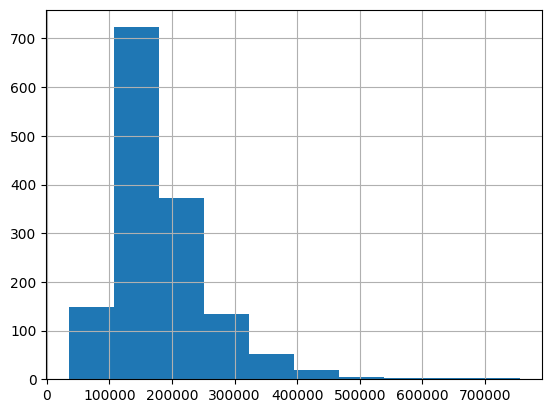

In [97]:
## 目的変数の統計量と分布（"SalePrice"）
print(train_data["SalePrice"].describe())
train_data["SalePrice"].hist()

### ⓶欠損値確認／処理

In [98]:
# 欠損値の確認
print(train_data.isnull().sum()[train_data.isnull().sum() > 0])
print((train_data.isnull().sum() > 0).sum())

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64
19


In [99]:
## データ型の確認
train_data.loc[:, train_data.isnull().any()].dtypes

LotFrontage     float64
Alley               str
MasVnrType          str
MasVnrArea      float64
BsmtQual            str
BsmtCond            str
BsmtExposure        str
BsmtFinType1        str
BsmtFinType2        str
Electrical          str
FireplaceQu         str
GarageType          str
GarageYrBlt     float64
GarageFinish        str
GarageQual          str
GarageCond          str
PoolQC              str
Fence               str
MiscFeature         str
dtype: object

In [100]:
# 欠損値の処理（消去：Alley/ MasVnrType/ PoolQC/ Fence/ MiscFeature）
train_data_handling= train_data.drop(columns=["Alley", "MasVnrType", "PoolQC", "Fence", "MiscFeature"])

# 欠損値の処理（中央値：LotFrontage/ MasVnrArea/ GarageYrBlt）
train_data_handling[["LotFrontage", "MasVnrArea", "GarageYrBlt"]]= (train_data_handling[["LotFrontage", "MasVnrArea", "GarageYrBlt"]].fillna(train_data_handling[["LotFrontage", "MasVnrArea", "GarageYrBlt"]].median()))

# 欠損値の処理（最頻値：BsmtQual/ BsmtCond/ BsmtExposure/ BsmtFinType1/ BsmtFinType2/ Electrical/ FireplaceQu/ GarageType/ GarageFinish/ GarageQual/ GarageCond）
train_data_handling["BsmtQual"]= train_data_handling["BsmtQual"].fillna(train_data_handling["BsmtQual"].mode()[0])
train_data_handling["BsmtCond"]= train_data_handling["BsmtCond"].fillna(train_data_handling["BsmtCond"].mode()[0])
train_data_handling["BsmtExposure"]= train_data_handling["BsmtExposure"].fillna(train_data_handling["BsmtExposure"].mode()[0])
train_data_handling["BsmtFinType1"]= train_data_handling["BsmtFinType1"].fillna(train_data_handling["BsmtFinType1"].mode()[0])
train_data_handling["BsmtFinType2"]= train_data_handling["BsmtFinType2"].fillna(train_data_handling["BsmtFinType2"].mode()[0])
train_data_handling["Electrical"]= train_data_handling["Electrical"].fillna(train_data_handling["Electrical"].mode()[0])
train_data_handling["FireplaceQu"]= train_data_handling["FireplaceQu"].fillna(train_data_handling["FireplaceQu"].mode()[0])
train_data_handling["GarageType"]= train_data_handling["GarageType"].fillna(train_data_handling["GarageType"].mode()[0])
train_data_handling["GarageFinish"]= train_data_handling["GarageFinish"].fillna(train_data_handling["GarageFinish"].mode()[0])
train_data_handling["GarageQual"]= train_data_handling["GarageQual"].fillna(train_data_handling["GarageQual"].mode()[0])
train_data_handling["GarageCond"]= train_data_handling["GarageCond"].fillna(train_data_handling["GarageCond"].mode()[0])

In [101]:
## 欠損値の確認
print(train_data_handling.isnull().sum()[train_data_handling.isnull().sum() > 0])
print((train_data_handling.isnull().sum() > 0).sum())
print(train_data_handling.isnull().sum().sum())


Series([], dtype: int64)
0
0


### ⓷カテゴリ変数を数値化処理

In [102]:
## データ型の確認
train_data_handling.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [103]:
## データ型/形の確認
print(train_data_handling.select_dtypes(include="str").columns)
print(train_data_handling.shape)

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='str')
(1460, 76)


In [104]:
# ダミー変数化処理
train_data_dummy= pd.get_dummies(
    train_data_handling,
    drop_first=True
)

In [105]:
## データ型/形の確認
print(train_data_dummy.select_dtypes(include="str").columns)
print(train_data_dummy.shape)

Index([], dtype='str')
(1460, 235)


### ⓸説明／目的変数の作成

In [106]:
# 説明変数Xと目的変数yの作成
X= train_data_dummy.drop(columns=["SalePrice"])
y= train_data_dummy["SalePrice"]

print(X.head())
print(y.head())

   Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0   1          60         65.0     8450            7            5       2003   
1   2          20         80.0     9600            6            8       1976   
2   3          60         68.0    11250            7            5       2001   
3   4          70         60.0     9550            7            5       1915   
4   5          60         84.0    14260            8            5       2000   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  SaleType_ConLI  SaleType_ConLw  \
0          2003       196.0         706  ...           False           False   
1          1976         0.0         978  ...           False           False   
2          2002       162.0         486  ...           False           False   
3          1970         0.0         216  ...           False           False   
4          2000       350.0         655  ...           False           False   

   SaleType_New  SaleType_Oth  SaleTyp

### ⓹学習／検証データの分割　

In [107]:
# 学習／検証データの分割
import sklearn.model_selection
X_train, X_test, y_train, y_test= sklearn.model_selection.train_test_split(X, y, random_state=0)

### ⓺モデルの学習

In [108]:
# 重回帰分析モデル
from sklearn.linear_model import LinearRegression
lr_model= LinearRegression()
lr_model.fit(X_train, y_train)
print(lr_model.score(X_train, y_train))
print(lr_model.score(X_test, y_test))

# Random Forest モデル
from sklearn.ensemble import RandomForestRegressor
rf_model= RandomForestRegressor(random_state=0)
rf_model.fit(X_train, y_train)
print(rf_model.score(X_train, y_train))
print(rf_model.score(X_test, y_test))

0.9418266508333722
0.6218904579837299
0.976988890502462
0.8391840702829786


### ⓻test.csv前処理

In [109]:
# testデータの読み込み/EDA
test_data= pd.read_csv("data/test.csv")
print(test_data.shape)
print(test_data.info())

(1459, 80)
<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [110]:
print(test_data.isnull().sum()[test_data.isnull().sum()>0])
print((test_data.isnull().sum() > 0).sum())

MSZoning           4
LotFrontage      227
Alley           1352
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType       894
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinSF1         1
BsmtFinType2      42
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu      730
GarageType        76
GarageYrBlt       78
GarageFinish      78
GarageCars         1
GarageArea         1
GarageQual        78
GarageCond        78
PoolQC          1456
Fence           1169
MiscFeature     1408
SaleType           1
dtype: int64
33


In [111]:
# 欠損値の処理（train時の消去処理：Alley/ MasVnrType/ PoolQC/ Fence/ MiscFeature）
test_data_handling= test_data.drop(columns=["Alley", "MasVnrType", "PoolQC", "Fence", "MiscFeature"])

# 欠損値の処理
test_data_handling[["LotFrontage", "MasVnrArea", "GarageYrBlt","BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "GarageCars", "GarageArea"]]= test_data_handling[["LotFrontage", "MasVnrArea", "GarageYrBlt","BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "GarageCars", "GarageArea"]].fillna(train_data_handling[["LotFrontage", "MasVnrArea", "GarageYrBlt","BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "GarageCars", "GarageArea"]].median())

# 欠損値の処理
test_data_handling["BsmtQual"]= test_data_handling["BsmtQual"].fillna(train_data_handling["BsmtQual"].mode()[0])
test_data_handling["BsmtCond"]= test_data_handling["BsmtCond"].fillna(train_data_handling["BsmtCond"].mode()[0])
test_data_handling["BsmtExposure"]= test_data_handling["BsmtExposure"].fillna(train_data_handling["BsmtExposure"].mode()[0])
test_data_handling["BsmtFinType1"]= test_data_handling["BsmtFinType1"].fillna(train_data_handling["BsmtFinType1"].mode()[0])
test_data_handling["BsmtFinType2"]= test_data_handling["BsmtFinType2"].fillna(train_data_handling["BsmtFinType2"].mode()[0])
test_data_handling["FireplaceQu"]= test_data_handling["FireplaceQu"].fillna(train_data_handling["FireplaceQu"].mode()[0])
test_data_handling["GarageType"]= test_data_handling["GarageType"].fillna(train_data_handling["GarageType"].mode()[0])
test_data_handling["GarageFinish"]= test_data_handling["GarageFinish"].fillna(train_data_handling["GarageFinish"].mode()[0])
test_data_handling["GarageQual"]= test_data_handling["GarageQual"].fillna(train_data_handling["GarageQual"].mode()[0])
test_data_handling["GarageCond"]= test_data_handling["GarageCond"].fillna(train_data_handling["GarageCond"].mode()[0])
test_data_handling["MSZoning"]= test_data_handling["MSZoning"].fillna(train_data_handling["MSZoning"].mode()[0])
test_data_handling["Utilities"]= test_data_handling["Utilities"].fillna(train_data_handling["Utilities"].mode()[0])
test_data_handling["Exterior1st"]= test_data_handling["Exterior1st"].fillna(train_data_handling["Exterior1st"].mode()[0])
test_data_handling["Exterior2nd"]= test_data_handling["Exterior2nd"].fillna(train_data_handling["Exterior2nd"].mode()[0])
test_data_handling["KitchenQual"]= test_data_handling["KitchenQual"].fillna(train_data_handling["KitchenQual"].mode()[0])
test_data_handling["Functional"]= test_data_handling["Functional"].fillna(train_data_handling["Functional"].mode()[0])
test_data_handling["SaleType"]= test_data_handling["SaleType"].fillna(train_data_handling["SaleType"].mode()[0])


In [112]:
print(test_data_handling.isnull().sum()[test_data_handling.isnull().sum()>0])
print((test_data_handling.isnull().sum() > 0).sum())

Series([], dtype: int64)
0


In [113]:
test_data_handling.loc[:, test_data_handling.isnull().any()].dtypes

Series([], dtype: object)

In [114]:
# ダミー変数化処理
test_data_dummy= pd.get_dummies(
    test_data_handling,
    drop_first=True
)

In [115]:
test_data_dummy.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Columns: 218 entries, Id to SaleCondition_Partial
dtypes: bool(181), float64(11), int64(26)
memory usage: 679.8 KB


In [116]:
print(test_data_dummy.select_dtypes(include="str").columns)
print(train_data_dummy.shape)
print(test_data_dummy.shape)

Index([], dtype='str')
(1460, 235)
(1459, 218)


In [117]:
# trainとtestのダミー変数化後の列数を一致させる処理
X = train_data_dummy.drop("SalePrice", axis=1)

X, test_data_dummy = X.align(
    test_data_dummy,
    join="left",
    axis=1,
    fill_value=0
)

In [118]:
set(train_data_dummy.columns) - set(test_data_dummy.columns)

{'SalePrice'}

In [119]:
set(test_data_dummy.columns) - set(train_data_dummy.columns)

set()

In [120]:
print(X.shape)
print(test_data_dummy.shape)

(1460, 234)
(1459, 234)


### ⓼test.csv予測

In [121]:
# 重回帰分析 modelでのtest.csv予測
pred_test_lr= lr_model.predict(test_data_dummy)
print(pred_test_lr)

# Random Forest modelでのtest.csv予測
pred_test_rf= rf_model.predict(test_data_dummy)
print(pred_test_rf)

[136307.26706964 203277.81842944 213832.93542232 ... 207206.64760945
 136431.99482092 248412.74023856]
[128767.58 158199.4  184754.59 ... 148962.87 107328.08 236126.13]


### ⓽提出ファイル作成

In [122]:
# 重回帰分析 model
submission_lr= pd.DataFrame({
    "Id": test_data["Id"],
    "SalePrice": pred_test_lr
})
submission_lr.to_csv("outcome/submission_lr.csv", index=False)


# Random Forest model
submission_rf= pd.DataFrame({
    "Id":test_data["Id"],
    "SalePrice": pred_test_rf
})
submission_rf.to_csv("outcome/submission_rf.csv", index=False) 

### 実行手順
① Random Forestで提出

② スコア確認

③ 特徴量エンジニアリング

④ XGBoost